Thesis: Preprocessing

In [ ]:
# Packs
import pandas as pd

In [ ]:
df1 = pd.read_excel('/content/HIC_dataset1.xlsx')
df2 = pd.read_excel('/content/HIC_dataset2.xlsx')
df3 = pd.read_excel('/content/HIC_dataset3.xlsx')
df4 = pd.read_excel('/content/HIC_dataset4.xlsx')
df5 = pd.read_excel('/content/HIC_dataset5.xlsx')
df6 = pd.read_excel('/content/HIC_dataset6.xlsx')

pd.set_option('display.max_colwidth', None)

In [ ]:
df2['sentiment label']

,sentiment label
0,[subjective];[Hamas: mildly negative;;medium][Israel: very positive;;high]
1,[subjective];[Hamas: na;;na][Israel: mildly positive;;medium]
2,[subjective];[Hamas: mildly negative;;medium][Israel: na;;na]
3,[subjective];[Hamas: na;;na][Israel: mildly negative;;medium]
4,[subjective];[Hamas: very negative;;medium][Israel: na;;na]
...,...
100995,[subjective];[Hamas: mildly negative;;medium][Israel: na;;na]
100996,[subjective];[Hamas: mildly positive;;medium][Israel: na;;na]
100997,[subjective];[Hamas: mildly negative;;medium][Israel: na;;na]
100998,[subjective];[Hamas: mildly negative;;medium][Israel: very positive;;high]


In [ ]:
# concat it all
df = pd.concat([df1, df2, df3, df4, df5, df6])

In [ ]:
df.columns

Index(['tweet_ID', 'tweet_pub_time', 'tweet_text', 'tweet_likes',
       'tweet_replies', 'tweet_reposts', 'account_ID', 'following_num',
       'followers_num', 'tweets_num', 'sentiment label'],
      dtype='object')

In [ ]:
from langdetect import detect
# @title Detect language
def detect_language(text):
    try:
        return detect(text)
    except:
        return 'error'

df['language'] = df['tweet_text'].apply(detect_language)
print(df['language'].value_counts())

## Keep only English tweets
english_usable_df = df[df['language'] == 'en'].copy()

print("Number of English tweets:", english_usable_df.shape[0])
print(english_usable_df[['tweet_text', 'language']].head(5))



language
en       343985
es        89293
pt        40681
fr        40241
de        20590
tr        15921
nl        10588
id        10450
it         9525
ca         4235
sv         4226
hi         3041
ar         2030
sw         1580
pl         1120
fa          949
da          900
et          851
fi          846
ur          812
no          806
cy          731
cs          645
el          532
hr          485
af          444
he          419
sl          412
tl          402
th          366
so          278
ro          267
lv          229
ta          192
ja           86
kn           70
hu           70
ru           68
zh-cn        60
vi           57
mr           54
error        48
lt           37
ne           30
uk           28
sq           21
ml           21
ko           20
gu           18
sk           15
te           12
zh-tw        10
bg            8
pa            4
bn            4
mk            1
Name: count, dtype: int64
Number of English tweets: 343985
                                    

KeyError: 'clean_text'

In [ ]:
# @title Saving English Tweets into csv file
english_usable_df.to_csv('Data_english_tweets.csv', index=False)


# From here on the English only tweets


In [ ]:
# Import packages
import pandas as pd

In [ ]:
df = pd.read_csv('/content/Data_english_tweets.csv')
pd.set_option('display.max_colwidth', None)

In [ ]:
df.describe()

,tweet_likes,tweet_replies,tweet_reposts,following_num,followers_num,tweets_num
count,343985.000000,343985.000000,343985.000000,3.439850e+05,3.439850e+05,3.439850e+05
mean,839.334936,78.430033,260.609710,5.669653e+03,6.644783e+05,9.063832e+04
std,4495.969859,497.709269,1555.026392,2.292354e+04,3.370156e+06,1.553781e+05
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00
25%,43.000000,6.000000,10.000000,5.480000e+02,6.619000e+03,1.238300e+04
50%,115.000000,13.000000,29.000000,1.459000e+03,3.485400e+04,3.366300e+04
75%,363.000000,35.000000,98.000000,4.116000e+03,1.712140e+05,9.483300e+04
max,653917.000000,72025.000000,186378.000000,1.414791e+06,1.661277e+08,2.295228e+06


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343985 entries, 0 to 343984
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   tweet_ID         343985 non-null  object
 1   tweet_pub_time   343985 non-null  object
 2   tweet_text       343985 non-null  object
 3   tweet_likes      343985 non-null  int64 
 4   tweet_replies    343985 non-null  int64 
 5   tweet_reposts    343985 non-null  int64 
 6   account_ID       343985 non-null  object
 7   following_num    343985 non-null  int64 
 8   followers_num    343985 non-null  int64 
 9   tweets_num       343985 non-null  int64 
 10  sentiment label  343985 non-null  object
 11  language         343985 non-null  object
dtypes: int64(6), object(6)
memory usage: 31.5+ MB


In [ ]:
df['tweet_text']

,tweet_text
0,"Tel Aviv, Israel on a Thursday at 3am. Wild af. Must be because of the holiday, Sukkot. https://t.co/bnyeeWefnO"
1,@swilkinsonbc So sick and tired of Israel mistreating Palestinians. Why won’t the international community intervene? https://t.co/BXoq58oyIo
2,"Two pieces at the Israel Museum were destroyed, the head of Athena and a statue representing the Roman god Nemesis. The vandal said they “went against Torah.” This is part of a fundamentalist Jewish turn that is terrifying. It’s most reminiscent of the Taliban. https://t.co/mVeQFoXlLG"
3,Israel is a constant target of both jihadists and the Biden Admin. We are going to the U.N. this week on behalf of Israel. Show your support by signing our petition to help protect our precious ally. https://t.co/zQU8S52rXr
4,"(3 of 3) - All Christians shouldn’t have to apologize for the actions of a couple of proselytizing instigators, and those kinds of minor events should be blown out of proportion in an attempt to attack Israel, and the Jews.\n\nThat’s my whole point. Neither all Christians, nor all Jews, nor all Muslims are responsible for the actions of any of their fellow Christians, Muslims, or Jews.\n\nAlso… and I feel like I’m being redundant here, but it seems like I have to be… nothing actually happened. 🤷‍♂️"
...,...
343980,"Nobody should be surprised by the support of the European Union and USA empires to the Zionist state of Israel on occupied Palestine. The history of colonization through genocide and dispossession by these empires is abundant in the history books. \n\nIt is ""civilized"" Europe against the ""savage"" indigenous people.\n\nIt is ""civilization"" against ""barbarism"" as the bigoted USA media portrays the conflict between Hamas ""terrorists"" vs ""chosen people""\n\nImagine 500 years ago the genocide against indigenous people when no cable news were available. The corpses of the ""uncivilized"" people are underground and the ""civilized"" ones continue the carnage in the year ""501"" . \n The Jewish intellectual, Noam Chomsky wrote a book with the title... ""THE YEAR 501: The conquest continues.\n#IsraelIsATerroristState"
343981,"Held hostage: Ofelia Roitman\n\n77-year-old Ofelia has been missing since October 7, when Hamas terrorists launched an assault on her Kibbutz Nir Oz. Ofelia had written to her family to tell them that terrorists were in her neighborhood. \n\nAt 9:37 a.m., the family received her last text message: “Please send help, the Palestinians are here,” she wrote.\n\nHer three children and nine grandchildren are desperate for her to come home. \n\nHelp bring Ofelia home. Demand Hamas release the hostages. #BringThemHome"
343982,"Adam, strict adherence to international laws includes the arrest and trial of Hamas terrorists. Think about what that entails, then think about the first bullet point in your post."
343983,"The truth.\nBiden is confused because his young voting base is protesting against Israel.\nBiden did not expect that,he thought their votes were safe after the student loan forgivness bribe.\nNow what will he do??\nThe WH is panicking to the point of overload.\n🤣🤣🤣🤣🤣🤣🤣"


In [ ]:
# Seperating the labels from Hamas and Israel and make new column out of it and rows
'''One will be for israel and its sentiment, and the other is hamas and sentiment
the ones with NA, will be deleted since there is not really information then provided.'''

df['sentiment label']

,sentiment label
0,[subjective];[Hamas: na;;na][Israel: mildly positive;;medium]
1,[subjective];[Hamas: mildly negative;;medium][Israel: mildly negative;;medium]
2,[subjective];[Hamas: na;;na][Israel: mildly negative;;medium]
3,[subjective];[Hamas: very negative;;high][Israel: very positive;;high]
4,[subjective];[Hamas: na;;na][Israel: neutral;;high]
...,...
343980,[subjective];[Hamas: mildly negative;;medium][Israel: very negative;;high]
343981,[subjective];[Hamas: very negative;;high][Israel: na;;na]
343982,[subjective];[Hamas: mildly negative;;medium][Israel: na;;na]
343983,[subjective];[Hamas: mildly negative;;medium][Israel: neutral;;high]


In [ ]:
import re

In [ ]:
def extract_entity_sentiment_from_label(row):
    label = row['sentiment label']
    results = []
    if not isinstance(label, str):
        return pd.DataFrame(columns=list(row.index) + ['entity', 'sentiment'])

    # Regex to capture entity and sentiment before the first ';;'
    matches = re.findall(r'\[([A-Za-z\s]+): ([^;\]]+)', label)

    for entity, sentiment in matches:
        # Add entity + sentiment to original row
        new_row = row.copy()
        new_row['entity'] = entity.strip()
        new_row['sentiment'] = sentiment.strip()
        results.append(new_row)

    return pd.DataFrame(results)

# Apply to all rows and flatten
df_expanded = pd.concat([extract_entity_sentiment_from_label(row) for _, row in df.iterrows()],
                        ignore_index=True)

print(df_expanded)

                 tweet_ID       tweet_pub_time  \
0       HIC_TWID_00000001  2023-10-06 08:05:16   
1       HIC_TWID_00000001  2023-10-06 08:05:16   
2       HIC_TWID_00000002  2023-10-06 08:21:41   
3       HIC_TWID_00000002  2023-10-06 08:21:41   
4       HIC_TWID_00000003  2023-10-06 08:22:00   
...                   ...                  ...   
687965  HIC_TWID_00608811  2023-10-31 07:59:51   
687966  HIC_TWID_00608812  2023-10-31 07:59:52   
687967  HIC_TWID_00608812  2023-10-31 07:59:52   
687968  HIC_TWID_00608813  2023-10-31 07:59:52   
687969  HIC_TWID_00608813  2023-10-31 07:59:52   

                                                                                                                                                                                                                                                                                                              tweet_text  \
0                                                                                  

In [ ]:

df_expanded = df_expanded[df_expanded['sentiment'] != 'na']
df_expanded = df_expanded[df_expanded['sentiment'] != 'positive']
df_expanded['sentiment'].value_counts()

,count
sentiment,
mildly negative,216499
very negative,83676
mildly positive,72514
neutral,64032
very positive,23819


In [ ]:
df_expanded['entity'].value_counts()

,count
entity,
Hamas,235417
Israel,225123


In [ ]:
df_expanded.to_csv('Data_Thesis.csv', index=False)

# Again saved and going on witht the Data_Thesis
Here we can actually do like the preprocessing

In [ ]:
import pandas as pd
import re
import emoji
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


filtering steps that applies in essence for the pre-trained models.

However, this will be also used for the ML, and DL models.

Preprocessing steps:

      - Filtering non-English tweets
      - Lowercasing
      - Removing special characters (including “@” and “#” while preserving the remaining token)
      - Removing URLs
      - Emoji tokenization
      - Replace user mentions '@' to '[USER]'
      - Normalizing whitespace


In [ ]:
df = pd.read_csv('/content/Data_Thesis.csv')
pd.set_option('display.max_colwidth', None)

In [ ]:
# Lowercasing
def lowercase_text(df):
    df['New_text'] = df['tweet_text'].str.lower()
    return df

df = lowercase_text(df)
print(df['New_text'].head())

0                                                                                                                                                                                  tel aviv, israel on a thursday at 3am. wild af. must be because of the holiday, sukkot. https://t.co/bnyeewefno
1                                                                                                                                                     @swilkinsonbc so sick and tired of israel mistreating palestinians. why won’t the international community intervene? https://t.co/bxoq58oyio
2                                                                                                                                                     @swilkinsonbc so sick and tired of israel mistreating palestinians. why won’t the international community intervene? https://t.co/bxoq58oyio
3    two pieces at the israel museum were destroyed, the head of athena and a statue representing the roman god nemesis. the va

In [ ]:
# Removing special characters (including “@” and “#” while preserving the remaining token)
# Function to remove only @ and # symbols

def remove_at_hash(text):
    """
    Replace @mentions with [USER]
    Remove # but keep the hashtag word
    """
    # Replace @username with [USER]
    text = re.sub(r'@\w+', '[USER]', text)

    # Remove # but keep the word (e.g., #Israel -> Israel)
    text = re.sub(r'#', '', text)

    return text   # ← THIS WAS MISSING

# Apply to the DataFrame column
df['New_text'] = df['New_text'].apply(remove_at_hash)

print(df['New_text'].head(5))

0                                                                                                                                                                                  tel aviv, israel on a thursday at 3am. wild af. must be because of the holiday, sukkot. https://t.co/bnyeewefno
1                                                                                                                                                            [USER] so sick and tired of israel mistreating palestinians. why won’t the international community intervene? https://t.co/bxoq58oyio
2                                                                                                                                                            [USER] so sick and tired of israel mistreating palestinians. why won’t the international community intervene? https://t.co/bxoq58oyio
3    two pieces at the israel museum were destroyed, the head of athena and a statue representing the roman god nemesis. the va

In [ ]:
# Removing URLs
def remove_urls(df):
    url_pattern = r'http\S+|www\S+|https\S+'
    df['New_text'] = df['New_text'].str.replace(url_pattern, '', regex=True)
    return df
df = remove_urls(df)
print(df[['New_text']].head())




                                                                                                                                                                                                                                                                 New_text
0                                                                                                                                                                                tel aviv, israel on a thursday at 3am. wild af. must be because of the holiday, sukkot. 
1                                                                                                                                                          [USER] so sick and tired of israel mistreating palestinians. why won’t the international community intervene? 
2                                                                                                                                                          [USER] so sick and tired of israel mistreating 

In [ ]:
print(df[['New_text']])

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  New_text
0                                                                                                                                                                                                                                                                                                                                                                                                                                                 tel aviv, israel on a thursday at 3am. wild

In [ ]:
# Emoji tokenization
def demojize_text(text):

    if not isinstance(text, str):
        return text
    return emoji.demojize(text)

# Apply to the DataFrame column
df['New_text'] = df['New_text'].apply(demojize_text)

# Test
print(df['New_text'])

0                                                                                                                                                                                                                                                                                                                                                                                                                                                   tel aviv, israel on a thursday at 3am. wild af. must be because of the holiday, sukkot. 
1                                                                                                                                                                                                                                                                                                                                                                                                                             [USER] so sick and tired of israel mistreating palestinians. 

In [ ]:
# @title Normalizing whitespace
def normalize_whitespace(text):
    """
    Normalize whitespace by:
    - Replacing multiple spaces/tabs/newlines with a single space
    - Stripping leading/trailing whitespace
    """
    text = re.sub(r'\s+', ' ', text)  # Replace multiple whitespace with single space
    return text.strip()               # Remove leading/trailing spaces

df['New_text'] = df['New_text'].apply(normalize_whitespace)

print(df['New_text'].head())

0                                                                                                                                                                                  tel aviv, israel on a thursday at 3am. wild af. must be because of the holiday, sukkot.
1                                                                                                                                                            [USER] so sick and tired of israel mistreating palestinians. why won’t the international community intervene?
2                                                                                                                                                            [USER] so sick and tired of israel mistreating palestinians. why won’t the international community intervene?
3    two pieces at the israel museum were destroyed, the head of athena and a statue representing the roman god nemesis. the vandal said they “went against torah.” this is part of a fundamentalist je

In [ ]:
df

,tweet_ID,tweet_pub_time,tweet_text,tweet_likes,tweet_replies,tweet_reposts,account_ID,following_num,followers_num,tweets_num,sentiment label,language,entity,sentiment,New_text
0,HIC_TWID_00000001,2023-10-06 08:05:16,"Tel Aviv, Israel on a Thursday at 3am. Wild af. Must be because of the holiday, Sukkot. https://t.co/bnyeeWefnO",270,19,13,HIC_ACID_00000001,20,127068,12925,[subjective];[Hamas: na;;na][Israel: mildly positive;;medium],en,Israel,mildly positive,"tel aviv, israel on a thursday at 3am. wild af. must be because of the holiday, sukkot."
1,HIC_TWID_00000002,2023-10-06 08:21:41,@swilkinsonbc So sick and tired of Israel mistreating Palestinians. Why won’t the international community intervene? https://t.co/BXoq58oyIo,39,5,5,HIC_ACID_00000002,1284,6185,19941,[subjective];[Hamas: mildly negative;;medium][Israel: mildly negative;;medium],en,Hamas,mildly negative,[USER] so sick and tired of israel mistreating palestinians. why won’t the international community intervene?
2,HIC_TWID_00000002,2023-10-06 08:21:41,@swilkinsonbc So sick and tired of Israel mistreating Palestinians. Why won’t the international community intervene? https://t.co/BXoq58oyIo,39,5,5,HIC_ACID_00000002,1284,6185,19941,[subjective];[Hamas: mildly negative;;medium][Israel: mildly negative;;medium],en,Israel,mildly negative,[USER] so sick and tired of israel mistreating palestinians. why won’t the international community intervene?
3,HIC_TWID_00000003,2023-10-06 08:22:00,"Two pieces at the Israel Museum were destroyed, the head of Athena and a statue representing the Roman god Nemesis. The vandal said they “went against Torah.” This is part of a fundamentalist Jewish turn that is terrifying. It’s most reminiscent of the Taliban. https://t.co/mVeQFoXlLG",1035,184,321,HIC_ACID_00000003,19828,30463,67752,[subjective];[Hamas: na;;na][Israel: mildly negative;;medium],en,Israel,mildly negative,"two pieces at the israel museum were destroyed, the head of athena and a statue representing the roman god nemesis. the vandal said they “went against torah.” this is part of a fundamentalist jewish turn that is terrifying. it’s most reminiscent of the taliban."
4,HIC_TWID_00000004,2023-10-06 08:33:01,Israel is a constant target of both jihadists and the Biden Admin. We are going to the U.N. this week on behalf of Israel. Show your support by signing our petition to help protect our precious ally. https://t.co/zQU8S52rXr,62,7,16,HIC_ACID_00000004,185,573060,18648,[subjective];[Hamas: very negative;;high][Israel: very positive;;high],en,Hamas,very negative,israel is a constant target of both jihadists and the biden admin. we are going to the u.n. this week on behalf of israel. show your support by signing our petition to help protect our precious ally.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
460535,HIC_TWID_00608810,2023-10-31 07:59:48,"Held hostage: Ofelia Roitman\n\n77-year-old Ofelia has been missing since October 7, when Hamas terrorists launched an assault on her Kibbutz Nir Oz. Ofelia had written to her family to tell them that terrorists were in her neighborhood. \n\nAt 9:37 a.m., the family received her last text message: “Please send help, the Palestinians are here,” she wrote.\n\nHer three children and nine grandchildren are desperate for her to come home. \n\nHelp bring Ofelia home. Demand Hamas release the hostages. #BringThemHome",825,50,438,HIC_ACID_00004514,3542,184106,25983,[subjective];[Hamas: very negative;;high][Israel: na;;na],en,Hamas,very negative,"held hostage: ofelia roitman 77-year-old ofelia has been missing since october 7, when hamas terrorists launched an assault on her kibbutz nir oz. ofelia had written to her family to tell them that terrorists were in her neighborhood. at 9:37 a.m., the family received her last text message: “please send help, the palestinians are here,” she wrote. her three children and nine grandchildren are desperate for her to come home. help bring ofelia home. demand hamas release the hostages. b

In [ ]:
df.to_csv('Data_Thesis_after_pre.csv', index=False)

# This was the preprocessing

What was done is:
  - Filtering non-English tweets

  - Lowercasing (if using uncased models)

  - Removing URLs (or replacing with [URL])

  - Replacing @mentions → [USER]

  - Removing # while keeping the token

  - Emoji tokenization

  - Normalizing whitespace



              

# EDA

  - Example of text, entity and sentiment
  - Class imbalance
  - Most frequent words

  

In [ ]:
# @title Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import STOPWORDS
from wordcloud import WordCloud
from google.colab import files

In [ ]:
# @title Uploading file

df = pd.read_csv('Data_Thesis_after_pre.csv')
pd.set_option('display.max_colwidth', None)

In [ ]:
df = df[['New_text', 'entity', 'sentiment']]

In [ ]:
# @title Example of text, entity and sentiment

df[(df['entity'] == 'Israel') & (df['sentiment'] == 'very negative')][19:20]

,New_text,entity,sentiment
893,my money is on israel false flag attacking itself so it has an excuse to steal more palestinian land…..,Israel,very negative


In [ ]:
df[(df['entity'] == 'Hamas') & (df['sentiment'] == 'very negative')][19:20]

,New_text,entity,sentiment
331,breaking : multiple civilian infrastructures hit by rockets fired by terrorists of gaza in tel aviv of israel. israelunderattack prayforisrael indiawithisrael,Hamas,very negative


In [ ]:
# @title Amount of data
# Checking with len rows
len(df)

460540

# Class Imbalance

In [ ]:
# @title Sentiment proportion
print('Amount Sentiment Label:')
sentiment_amount = df['sentiment'].value_counts()
for label, amount in sentiment_amount.items():
  print(f"  {label}: {amount}")
print()
sentiment_proportions = df['sentiment'].value_counts(normalize=True) * 100
print('Proportions Sentiment Label:')
for label, percentage in sentiment_proportions.items():
  print(f"  {label}: {percentage:.2f}%")

Amount Sentiment Label:
  mildly negative: 216499
  very negative: 83676
  mildly positive: 72514
  neutral: 64032
  very positive: 23819

Proportions Sentiment Label:
  mildly negative: 47.01%
  very negative: 18.17%
  mildly positive: 15.75%
  neutral: 13.90%
  very positive: 5.17%


In [ ]:
# @title Entity proportion
print('Amount Entity Label:')
entity_amount = df['entity'].value_counts()
for label, amount in entity_amount.items():
  print(f"  {label}: {amount}")
print()
entity_proportions = df['entity'].value_counts(normalize=True) * 100
print('Proportions Entity Label:')
for label, percentage in entity_proportions.items():
  print(f"  {label}: {percentage:.2f}%")

Amount Entity Label:
  Hamas: 235417
  Israel: 225123

Proportions Entity Label:
  Hamas: 51.12%
  Israel: 48.88%


In [ ]:
for entity in df['entity'].unique():
  print(f"\nEntity: {entity}")
  sentiment_counts = df[df['entity'] == entity]['sentiment'].value_counts()
  print(sentiment_counts)


Entity: Israel
sentiment
mildly negative    76879
mildly positive    53928
neutral            50080
very positive      23491
very negative      20745
Name: count, dtype: int64

Entity: Hamas
sentiment
mildly negative    139620
very negative       62931
mildly positive     18586
neutral             13952
very positive         328
Name: count, dtype: int64


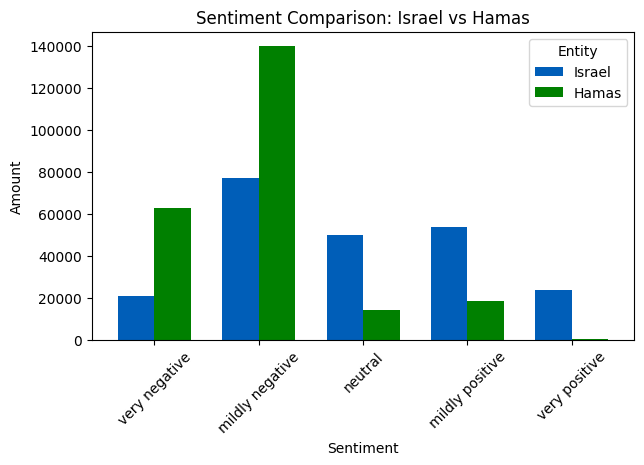

In [ ]:
# @title Bar Plot Hamas/Israel Sentiment Plot

# Define order
sentiment_order = [
    'very negative',
    'mildly negative',
    'neutral',
    'mildly positive',
    'very positive'
]

israel_sentiment = df[df['entity'] == 'Israel']['sentiment'].value_counts().reindex(sentiment_order)
hamas_sentiment = df[df['entity'] == 'Hamas']['sentiment'].value_counts().reindex(sentiment_order)

combined = pd.DataFrame({
    'Israel': israel_sentiment,
    'Hamas': hamas_sentiment
    }).fillna(0)

# Plot
combined.plot(kind='bar', figsize=(7,4), color=['#005EB8', '#008000'], width=0.7)

plt.xlabel('Sentiment')
plt.ylabel('Amount')
plt.title('Sentiment Comparison: Israel vs Hamas')
plt.xticks(rotation=45)
plt.legend(title='Entity')

plt.savefig('methodology_sentiment_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
sentiment_counts

,count
sentiment,
mildly negative,139620
very negative,62931
mildly positive,18586
neutral,13952
very positive,328


In [ ]:
# @title Generating Word Cloud
'''
Setting up the text data for the word cloud
  - make list
  - having only words
  - lowering
  - removing stopwords
  - removing user
'''

text = ' '.join(df['New_text'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
stopwords.add("user")



text = ' '.join(word for word in text.split() if word not in stopwords)

In [ ]:
worldcloud = WordCloud(width=800, height=400,background_color='black', max_words=100).generate(text)

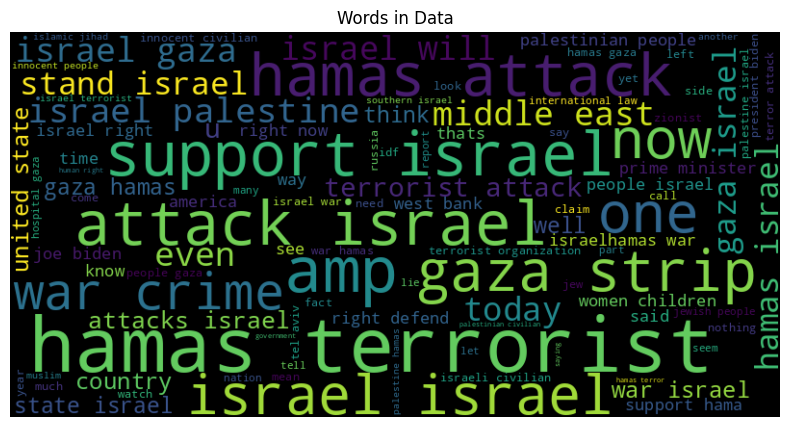

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(worldcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Words in Data')
worldcloud.to_file('wordcloud.png')
plt.show()

In [ ]:
df['sentiment'] = df['sentiment'].replace({
    'very negative'   : 'negative',
    'mildly negative' : 'negative',
    'neutral'         : 'neutral',
    'mildly positive' : 'positive',
    'very positive'   : 'positive',
})

df['sentiment'].value_counts()

,count
sentiment,
negative,300175
positive,96333
neutral,64032


In [ ]:
# @title Initializing sentiment

df_negative = df[df['sentiment'] == 'negative']
df_neutral = df[df['sentiment'] == 'neutral']
df_positive = df[df['sentiment'] == 'positive']




In [ ]:
# @title Negative: Generating Word Cloud
'''
Setting up the text data for the word cloud
  - make list
  - having only words
  - lowering
  - removing stopwords
  - removing user
'''

text = ' '.join(df_negative['New_text'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
stopwords.add("user")



text = ' '.join(word for word in text.split() if word not in stopwords)

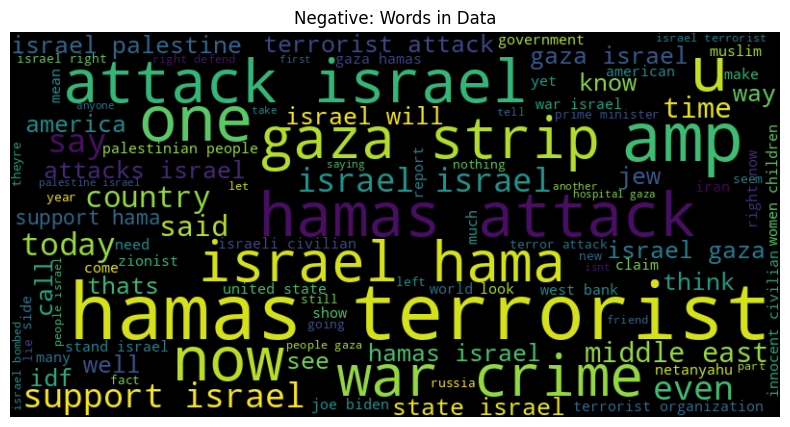

In [ ]:
text_negative = df_negative['New_text']
worldcloud = WordCloud(width=800, height=400,background_color='black', max_words=100).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(worldcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Negative: Words in Data')
worldcloud.to_file('negative_wordcloud.png')
plt.show()

In [ ]:
# @title Neutral: Generating Word Cloud
'''
Setting up the text data for the word cloud
  - make list
  - having only words
  - lowering
  - removing stopwords
  - removing user
'''

text = ' '.join(df_neutral['New_text'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
stopwords.add("user")



text = ' '.join(word for word in text.split() if word not in stopwords)

worldcloud = WordCloud(width=800, height=400,background_color='black', max_words=100).generate(text)

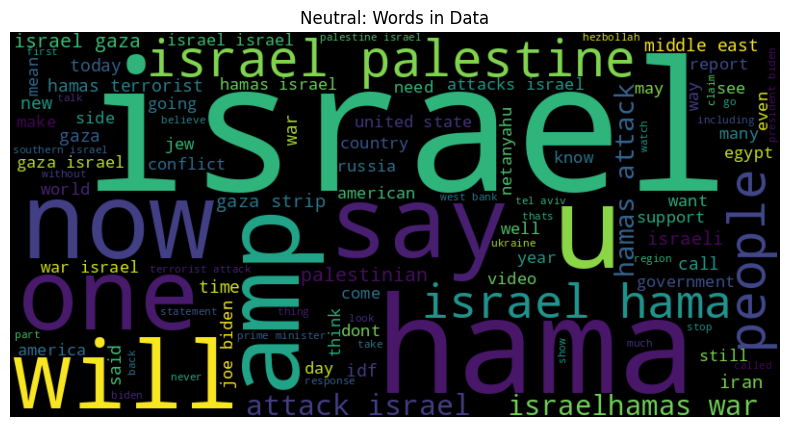

In [ ]:
text_negative = df_negative['New_text']
worldcloud = WordCloud(width=800, height=400,background_color='black', max_words=100).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(worldcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Neutral: Words in Data')
worldcloud.to_file('neutral_wordcloud.png')
plt.show()

In [ ]:
# @title Positive: Generating Word Cloud
'''
Setting up the text data for the word cloud
  - make list
  - having only words
  - lowering
  - removing stopwords
  - removing user
'''

text = ' '.join(df_positive['New_text'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
stopwords.add("user")



text = ' '.join(word for word in text.split() if word not in stopwords)

worldcloud = WordCloud(width=800, height=400,background_color='black', max_words=100).generate(text)

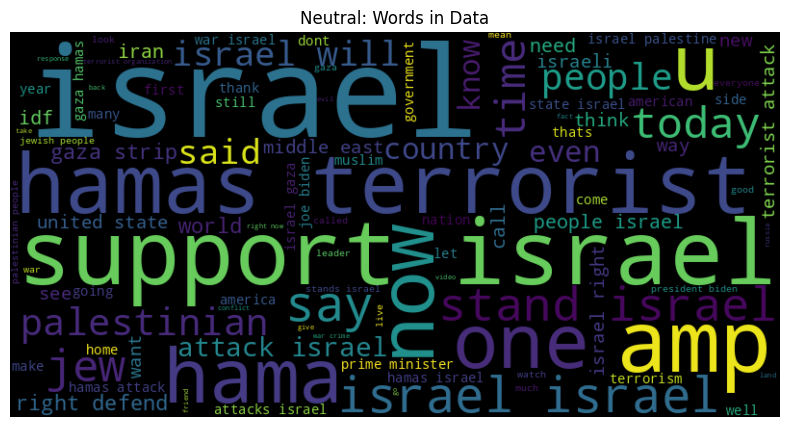

In [ ]:
text_negative = df_negative['New_text']
worldcloud = WordCloud(width=800, height=400,background_color='black', max_words=100).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(worldcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Neutral: Words in Data')
worldcloud.to_file('positive_wordcloud.png')
plt.show()